### **Imports**

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                               confusion_matrix,
                               roc_auc_score, roc_curve)


### **Load & Explore Data**

In [108]:
df = pd.read_csv('heart.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")


Shape: (918, 12)
Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']



In [109]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [111]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [112]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### **EDA**

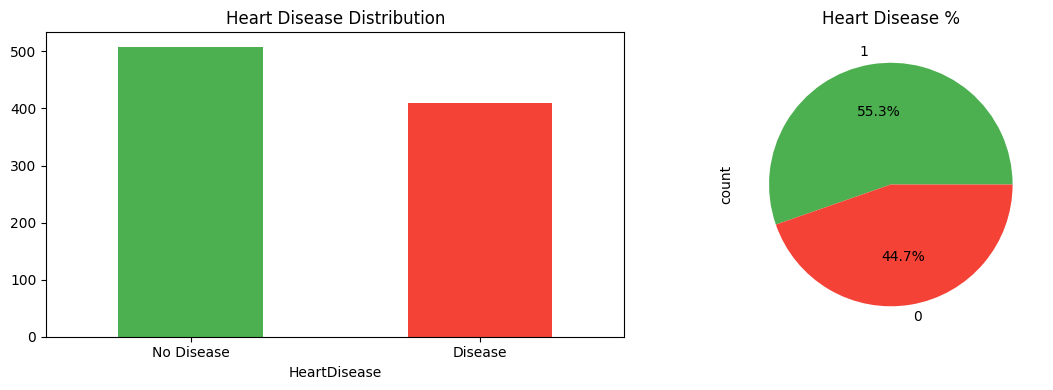

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['HeartDisease'].value_counts().plot(kind='bar', ax=axes[0],color=['#4CAF50', '#F44336'])
axes[0].set_title('Heart Disease Distribution')
axes[0].set_xticklabels(['No Disease', 'Disease'], rotation=0)
df['HeartDisease'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#4CAF50', '#F44336'])
axes[1].set_title('Heart Disease %')

plt.tight_layout()
plt.show()

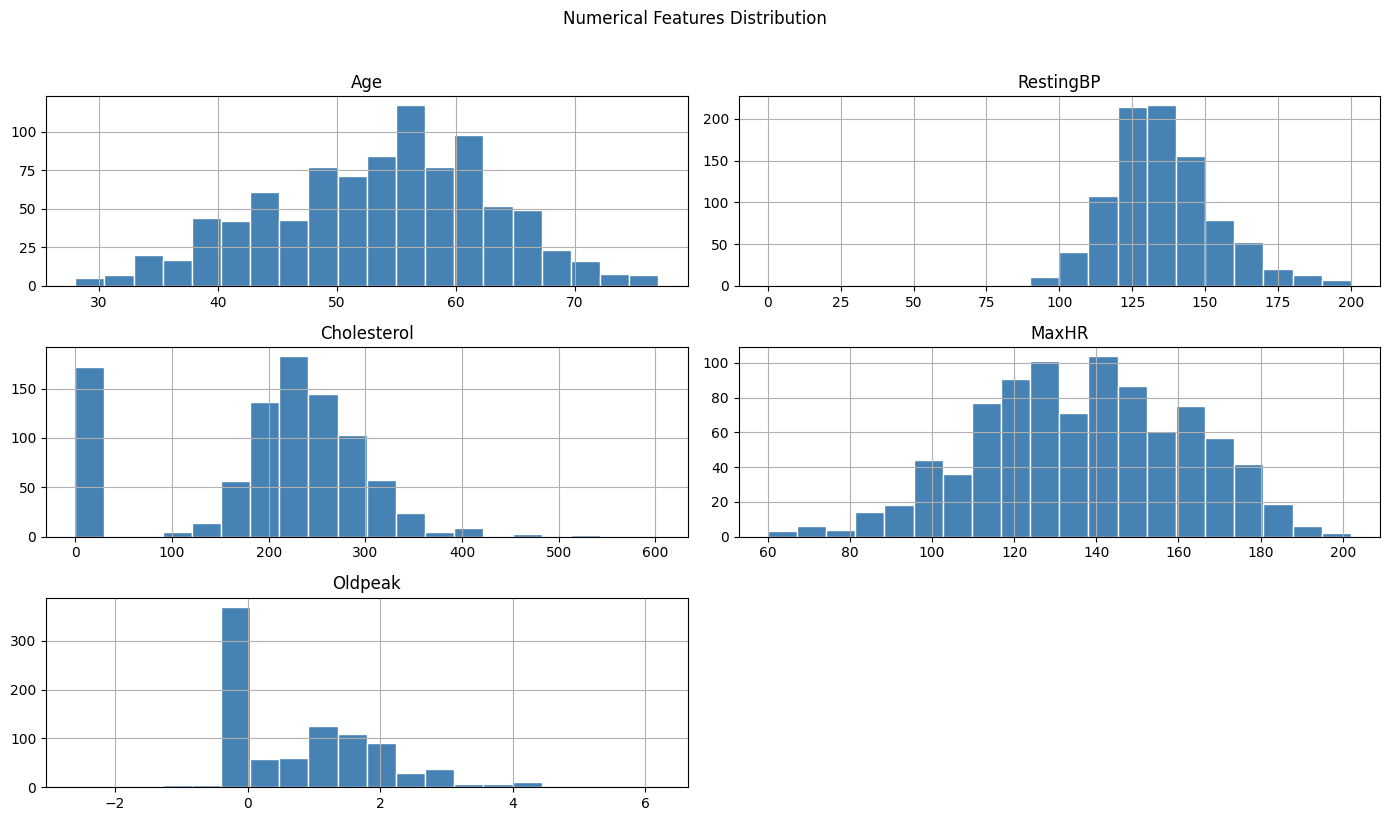

In [114]:
# Histograms for nummerical features
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df[num_cols].hist(figsize=(14, 8), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Numerical Features Distribution', y=1.02)
plt.tight_layout()
plt.show()

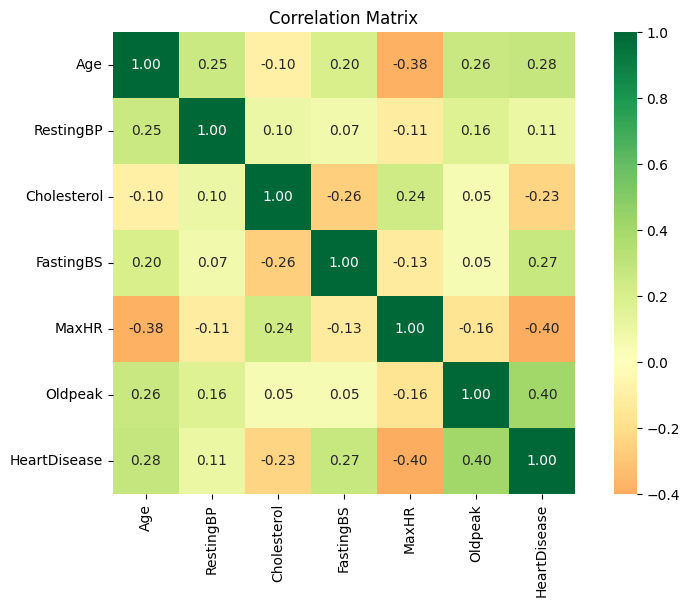

In [115]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True)
plt.title('Correlation Matrix')
plt.show()

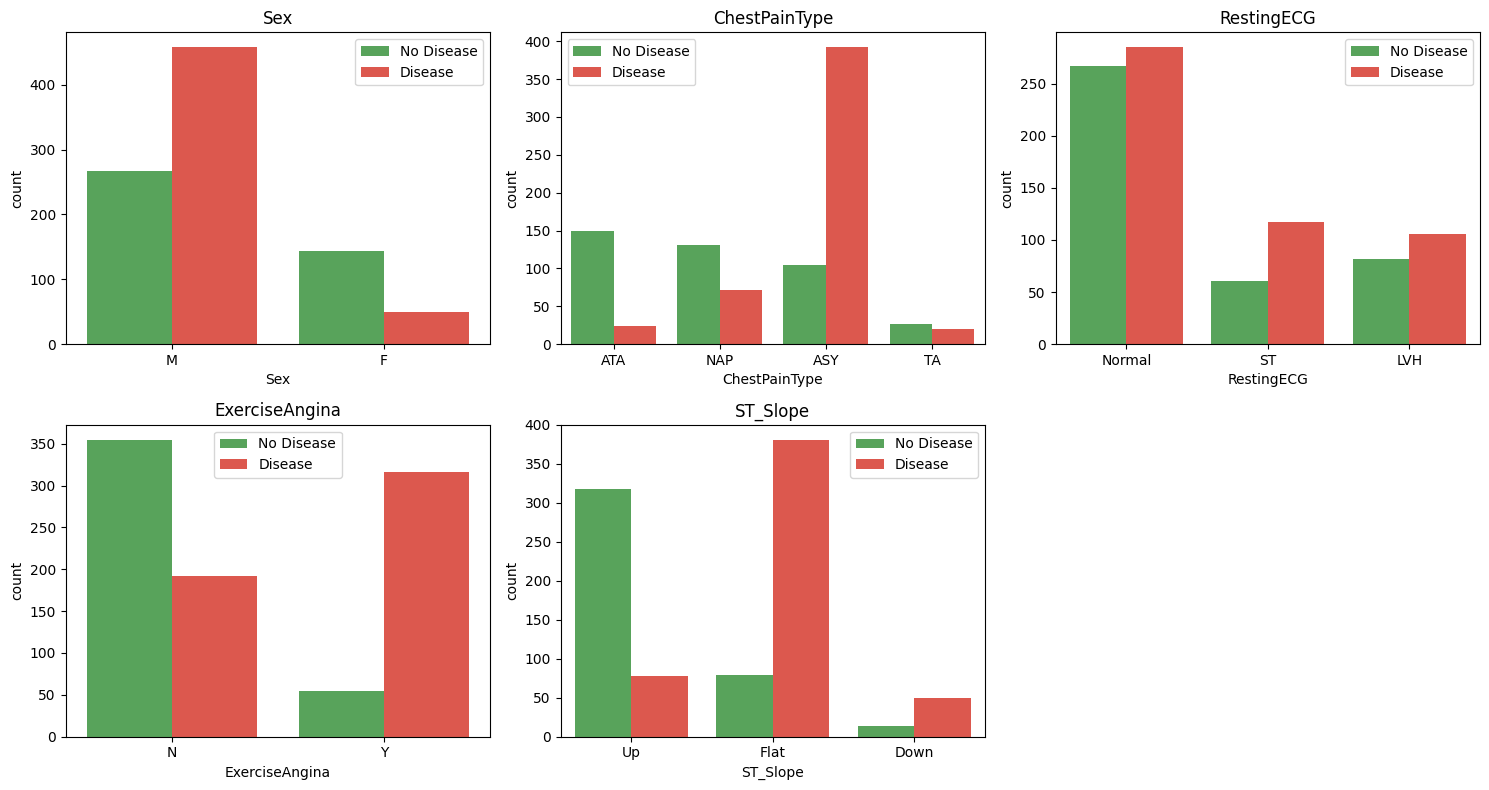

In [116]:
# Categorical Features vs HeartDisease
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='HeartDisease', ax=axes[i],
                  palette=['#4CAF50', '#F44336'])
    axes[i].set_title(col)
    axes[i].legend(['No Disease', 'Disease'])
axes[5].set_visible(False)
plt.tight_layout()
plt.show()

## **Data Preprocessing**

### **Handling wrong zeros**
Cholesterol and RestingBP contain physiologically impossible zero values,
likely recorded as 0 when data was missing.
We replace them with the median of valid (non-zero) readings
to avoid distorting the model without losing any rows.

In [117]:
print((df['Cholesterol'] == 0).sum())
print((df['RestingBP'] == 0).sum())

172
1


In [118]:
median_chol = df[df['Cholesterol'] != 0]['Cholesterol'].median()
median_bp   = df[df['RestingBP'] != 0]['RestingBP'].median()

df['Cholesterol'] = df['Cholesterol'].replace(0, median_chol)
df['RestingBP']   = df['RestingBP'].replace(0, median_bp)


#### **Label Encoding**

In [119]:
df_processed = df.copy()
le = LabelEncoder()
df_processed['Sex'] = le.fit_transform(df_processed['Sex'])
df_processed['ExerciseAngina'] = le.fit_transform(df_processed['ExerciseAngina'])
print(df[['Sex', 'ExerciseAngina']].head())

  Sex ExerciseAngina
0   M              N
1   F              N
2   M              N
3   F              Y
4   M              N


#### **One Hot Encoding**

In [120]:
df_processed = pd.get_dummies(
    df_processed,
    columns=['ChestPainType', 'RestingECG', 'ST_Slope'],
    drop_first=True
)

print(df_processed.shape)
print(df_processed.columns.tolist())

(918, 16)
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


#### **Feature Scaling & Splitting Data**

In [121]:
# Features & Target
X = df_processed.drop('HeartDisease', axis=1)
y = df_processed['HeartDisease']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 734 | Test size: 184


# Training Model

## logistic regression

In [122]:
# Logistic Regression Model
model = LogisticRegression(random_state=42)
# Train model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [128]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [124]:

# Accuracy Table
accuracy = model.score(X_test, y_test)

accuracy_df = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Value": [accuracy]
})

styled_accuracy = (
    accuracy_df.style
    .set_caption("Model Accuracy")
    .set_properties(**{
        'text-align': 'center',
        'font-size': '14px'
    })
)
display(styled_accuracy)

# Classification Report Table
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

display(
    report_df.style
    .set_caption("Classification Report")
    .background_gradient(cmap="RdPu")
    .set_properties(**{
        'text-align': 'center',
        'font-size': '13px'
    })
)


,Metric,Value
0,Accuracy,0.891304


,precision,recall,f1-score,support
0,0.887500,0.865854,0.876543,82.000000
1,0.894231,0.911765,0.902913,102.000000
accuracy,0.891304,0.891304,0.891304,0.891304
macro avg,0.890865,0.888809,0.889728,184.000000
weighted avg,0.891231,0.891304,0.891161,184.000000


In [125]:
# Confusion Matrix Table
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual No Disease", "Actual Disease"],
    columns=["Predicted No Disease", "Predicted Disease"]
)

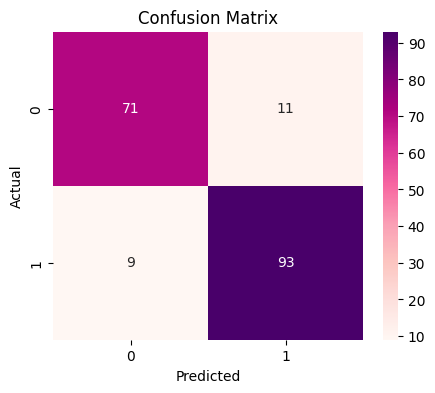

In [126]:
# Visualize Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC AUC Score: 0.9326877092300334


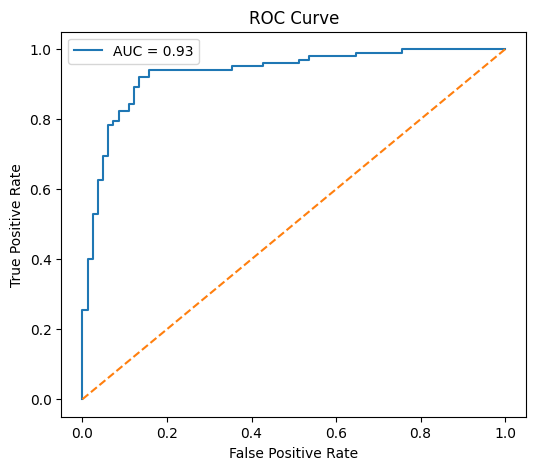

In [127]:
# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", roc_auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()